## Team Members

| Name                | Student ID  | Email                     |
|---------------------|------------|---------------------------|
| AARJEYAN SHRESTHA  | C0927422   | C0927422@mylambton.ca     |
| PRAJWAL LUITEL     | C0927658   | C0927658@mylambton.ca     |
| RAJAN GHIMIRE      | C0924991   | C0924991@mylambton.ca     |
| RISHABH JHA        | C0923563   | C0923563@mylambton.ca     |
| SUDIP CHAUDHARY    | C0922310   | C0922310@mylambton.ca     |


## Neural Network Architecture: Previous vs. Improved

### Class Structure
**Previous:**
- Simple `Neuron` class with basic functionality
- Monolithic `NeuralNetwork` class handling all aspects of the neural network

**Improved:**
- Modular design with specialized classes:
  - `ActivationFunctions` class with multiple activation options
  - `LossFunctions` class with different loss function implementations
  - Base `Layer` class with derived implementations
  - Separate `TextProcessor` and `Chatbot` classes

### Neural Network Capabilities

**Previous:**
- Fixed sigmoid activation function only
- Only Mean Squared Error loss function
- Single training method with no validation
- No regularization techniques
- Full-batch gradient descent only

**Improved:**
- Multiple activation functions (Sigmoid, ReLU, Softmax)
- Multiple loss functions (MSE, Cross-Entropy)
- Mini-batch gradient descent
- Early stopping based on validation performance
- Dropout regularization to prevent overfitting
- Proper weight initialization (Xavier/Glorot)

## New Features Added

### 1. Advanced Training Capabilities
- **Validation Split:** Added ability to validate on unseen data
- **Early Stopping:** Prevents overfitting by monitoring validation loss
- **Batch Processing:** More efficient and effective training
- **Learning Curves:** Added visualization of training history

### 2. Model Persistence
- **Save/Load Functionality:** Added ability to save and load models
- **JSON Format:** Model parameters stored in human-readable format

### 3. Enhanced Text Processing
- **Dedicated TextProcessor Class:** Better separation of concerns
- **Improved Tokenization:** More robust text handling

### 4. Improved Prediction
- **Confidence Threshold:** Added confidence-based response selection
- **Default Responses:** Added fallback for low-confidence predictions

### 5. Code Quality Improvements
- **Type Annotations:** Added throughout for better code documentation
- **Documentation:** Comprehensive docstrings for all methods
- **Error Handling:** Added proper exception handling

### 6. Additional Chatbot Features
- **Expanded Intent Recognition:** Improved pattern matching
- **Confidence Scoring:** Reports confidence level with predictions
- **Interactive Interface:** Enhanced user experience in chat mode



In [ ]:
# Import necessary libraries
import numpy as np
import re
import json
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from typing import List, Dict, Tuple, Union, Optional, Any

## Activation function and Loss function

### Activation functions with their derivatives

![](https://i3.wp.com/cdn-images-1.medium.com/max/950/1*CUPBA3fs9IFYZwBJqOgGBA.gif?ssl=1&w=800&resize=800&ssl=1)

In [ ]:
class ActivationFunctions:
    """Class containing various activation functions and their derivatives."""

    @staticmethod
    def sigmoid(z: np.ndarray) -> np.ndarray:
        """
        Sigmoid activation function.

        Args:
            z (np.ndarray): Input values

        Returns:
            np.ndarray: Sigmoid of input values
        """
        # Clip values to avoid overflow
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    @staticmethod
    def sigmoid_derivative(z: np.ndarray) -> np.ndarray:
        """
        Derivative of the sigmoid function.

        Args:
            z (np.ndarray): Input values

        Returns:
            np.ndarray: Derivative of sigmoid at input values
        """
        s = ActivationFunctions.sigmoid(z)
        return s * (1 - s)

    @staticmethod
    def relu(z: np.ndarray) -> np.ndarray:
        """
        ReLU activation function.

        Args:
            z (np.ndarray): Input values

        Returns:
            np.ndarray: ReLU of input values
        """
        return np.maximum(0, z)

    @staticmethod
    def relu_derivative(z: np.ndarray) -> np.ndarray:
        """
        Derivative of the ReLU function.

        Args:
            z (np.ndarray): Input values

        Returns:
            np.ndarray: Derivative of ReLU at input values
        """
        return np.where(z > 0, 1, 0)

    @staticmethod
    def softmax(z: np.ndarray) -> np.ndarray:
        """
        Softmax activation function.

        Args:
            z (np.ndarray): Input values

        Returns:
            np.ndarray: Softmax of input values
        """
        # Subtract max for numerical stability
        exp_z = np.exp(z - np.max(z))
        return exp_z / exp_z.sum(axis=0, keepdims=True)




## Loss function with their derivaties

![](https://rstudio-conf-2020.github.io/dl-keras-tf/02-hello-dl-world_files/figure-html/unnamed-chunk-76-1.gif)

In [ ]:
class LossFunctions:
    """Class containing various loss functions and their derivatives."""

    @staticmethod
    def mse(output: np.ndarray, target: np.ndarray) -> float:
        """
        Mean Squared Error loss.

        Args:
            output (np.ndarray): Predicted values
            target (np.ndarray): True values

        Returns:
            float: MSE loss
        """
        return np.mean((output - target) ** 2)

    @staticmethod
    def mse_derivative(output: np.ndarray, target: np.ndarray) -> np.ndarray:
        """
        Derivative of MSE loss.

        Args:
            output (np.ndarray): Predicted values
            target (np.ndarray): True values

        Returns:
            np.ndarray: Derivative of MSE loss
        """
        return 2 * (output - target) / output.size

    @staticmethod
    def cross_entropy(output: np.ndarray, target: np.ndarray) -> float:
        """
        Cross Entropy loss for multi-class classification.

        Args:
            output (np.ndarray): Predicted probabilities
            target (np.ndarray): One-hot encoded true labels

        Returns:
            float: Cross entropy loss
        """
        # Add small epsilon to avoid log(0)
        epsilon = 1e-15
        output = np.clip(output, epsilon, 1 - epsilon)
        return -np.sum(target * np.log(output)) / output.shape[1]

    @staticmethod
    def cross_entropy_derivative(output: np.ndarray, target: np.ndarray) -> np.ndarray:
        """
        Derivative of Cross Entropy loss.

        Args:
            output (np.ndarray): Predicted probabilities
            target (np.ndarray): One-hot encoded true labels

        Returns:
            np.ndarray: Derivative of cross entropy loss
        """
        # Add small epsilon to avoid division by zero
        epsilon = 1e-15
        output = np.clip(output, epsilon, 1 - epsilon)
        return -target / output / output.shape[1]

## Defining the Neural Network layer

![](https://community.alteryx.com/t5/image/serverpage/image-id/42339i8BA3F2CCCEDE7458/image-size/large?v=v2&px=999)

In [ ]:
class Layer:
    """Base class for neural network layers."""

    def forward(self, inputs: np.ndarray) -> np.ndarray:
        """Forward pass through the layer."""
        raise NotImplementedError

    def backward(self, grad: np.ndarray) -> np.ndarray:
        """Backward pass through the layer."""
        raise NotImplementedError

    def update(self, learning_rate: float) -> None:
        """Update layer parameters."""
        pass

    def get_parameters(self) -> List:
        """Get layer parameters."""
        return []

class DenseLayer(Layer):
  """Fully connected layer."""

  def __init__(self, input_size: int, output_size: int, activation: str = 'sigmoid'):
      """
      Initialize the dense layer.

      Args:
          input_size (int): Number of input features
          output_size (int): Number of output features
          activation (str): Activation function name
      """
      self.input_size = input_size
      self.output_size = output_size

      # Xavier/Glorot initialization for better convergence
      self.weights = np.random.randn(output_size, input_size) * np.sqrt(2 / (input_size + output_size))
      self.biases = np.zeros((output_size, 1))

      # Set activation function
      if activation == 'sigmoid':
          self.activation_fn = ActivationFunctions.sigmoid
          self.activation_derivative = ActivationFunctions.sigmoid_derivative
      elif activation == 'relu':
          self.activation_fn = ActivationFunctions.relu
          self.activation_derivative = ActivationFunctions.relu_derivative
      elif activation == 'softmax':
          self.activation_fn = ActivationFunctions.softmax
          self.activation_derivative = None  # Handled specially in backward
      else:
          raise ValueError(f"Unsupported activation function: {activation}")

      self.activation_name = activation

      # Cache for backward pass
      self.inputs = None
      self.z = None
      self.output = None

      # Gradients
      self.dW = None
      self.db = None

  def forward(self, inputs: np.ndarray) -> np.ndarray:
      """
      Forward pass through the layer.

      Args:
          inputs (np.ndarray): Input values

      Returns:
          np.ndarray: Layer output after activation
      """
      self.inputs = inputs
      self.z = np.dot(self.weights, inputs) + self.biases
      self.output = self.activation_fn(self.z)
      return self.output

  def backward(self, grad: np.ndarray) -> np.ndarray:
      """
      Backward pass through the layer.

      Args:
          grad (np.ndarray): Gradient from the next layer

      Returns:
          np.ndarray: Gradient to pass to the previous layer
      """
      if self.activation_name == 'softmax':
          # Special case for softmax + cross-entropy
          delta = grad
      else:
          delta = grad * self.activation_derivative(self.z)

      self.dW = np.dot(delta, self.inputs.T)
      self.db = np.sum(delta, axis=1, keepdims=True)

      # Gradient to pass to the previous layer
      return np.dot(self.weights.T, delta)

  def update(self, learning_rate: float) -> None:
      """
      Update layer parameters using gradient descent.

      Args:
          learning_rate (float): Learning rate
      """
      self.weights -= learning_rate * self.dW
      self.biases -= learning_rate * self.db

  def get_parameters(self) -> List:
      """
      Get layer parameters.

      Returns:
          List: Layer weights and biases
      """
      return [self.weights, self.biases]


### Dropout layer to set reularization

In [ ]:
class DropoutLayer(Layer):
    """Dropout layer for regularization."""

    def __init__(self, dropout_rate: float = 0.5):
        """
        Initialize the dropout layer.

        Args:
            dropout_rate (float): Probability of dropping a neuron
        """
        self.dropout_rate = dropout_rate
        self.mask = None

    def forward(self, inputs: np.ndarray, training: bool = True) -> np.ndarray:
        """
        Forward pass through the layer.

        Args:
            inputs (np.ndarray): Input values
            training (bool): Whether in training mode

        Returns:
            np.ndarray: Output after dropout
        """
        if not training:
            return inputs

        # Create dropout mask
        self.mask = np.random.binomial(1, 1 - self.dropout_rate, size=inputs.shape) / (1 - self.dropout_rate)
        return inputs * self.mask

    def backward(self, grad: np.ndarray) -> np.ndarray:
        """
        Backward pass through the layer.

        Args:
            grad (np.ndarray): Gradient from the next layer

        Returns:
            np.ndarray: Gradient with dropout applied
        """
        return grad * self.mask

## The Neural Network

In [ ]:
class NeuralNetwork:
    """Neural network with multiple layers."""

    def __init__(self):
        """Initialize the neural network."""
        self.layers = []
        self.loss_fn = None
        self.loss_derivative = None

    def add(self, layer: Layer) -> None:
        """
        Add a layer to the network.

        Args:
            layer (Layer): Layer to add
        """
        self.layers.append(layer)

    def set_loss(self, loss_type: str) -> None:
        """
        Set the loss function.

        Args:
            loss_type (str): Loss function name
        """
        if loss_type == 'mse':
            self.loss_fn = LossFunctions.mse
            self.loss_derivative = LossFunctions.mse_derivative
        elif loss_type == 'cross_entropy':
            self.loss_fn = LossFunctions.cross_entropy
            self.loss_derivative = LossFunctions.cross_entropy_derivative
        else:
            raise ValueError(f"Unsupported loss function: {loss_type}")

    def forward(self, x: np.ndarray, training: bool = True) -> np.ndarray:
        """
        Forward pass through the network.

        Args:
            x (np.ndarray): Input values
            training (bool): Whether in training mode

        Returns:
            np.ndarray: Network output
        """
        output = x
        for layer in self.layers:
            if isinstance(layer, DropoutLayer):
                output = layer.forward(output, training)
            else:
                output = layer.forward(output)
        return output

    def compute_loss(self, y_pred: np.ndarray, y_true: np.ndarray) -> float:
        """
        Compute the loss.

        Args:
            y_pred (np.ndarray): Predicted values
            y_true (np.ndarray): True values

        Returns:
            float: Loss value
        """
        return self.loss_fn(y_pred, y_true)

    def backward(self, y_pred: np.ndarray, y_true: np.ndarray) -> None:
        """
        Backward pass through the network.

        Args:
            y_pred (np.ndarray): Predicted values
            y_true (np.ndarray): True values
        """
        # Initial gradient from the loss function
        grad = self.loss_derivative(y_pred, y_true)

        # Propagate gradient through layers in reverse order
        for layer in reversed(self.layers):
            grad = layer.backward(grad)

    def update(self, learning_rate: float) -> None:
        """
        Update network parameters.

        Args:
            learning_rate (float): Learning rate
        """
        for layer in self.layers:
            layer.update(learning_rate)

    def train(self, x: np.ndarray, y: np.ndarray, learning_rate: float) -> float:
        """
        Train the network on a single batch.

        Args:
            x (np.ndarray): Input batch
            y (np.ndarray): Target batch
            learning_rate (float): Learning rate

        Returns:
            float: Batch loss
        """
        # Forward pass
        y_pred = self.forward(x, training=True)

        # Compute loss
        loss = self.compute_loss(y_pred, y)

        # Backward pass
        self.backward(y_pred, y)

        # Update parameters
        self.update(learning_rate)

        return loss

    def evaluate(self, x: np.ndarray, y: np.ndarray) -> Tuple[float, float]:
        """
        Evaluate the network on validation data.

        Args:
            x (np.ndarray): Input data
            y (np.ndarray): Target data

        Returns:
            Tuple[float, float]: Loss and accuracy
        """
        # Forward pass in evaluation mode
        y_pred = self.forward(x, training=False)

        # Compute loss
        loss = self.compute_loss(y_pred, y)

        # Compute accuracy for classification
        predicted_classes = np.argmax(y_pred, axis=0)
        true_classes = np.argmax(y, axis=0)
        accuracy = np.mean(predicted_classes == true_classes)

        return loss, accuracy

    def predict(self, x: np.ndarray) -> np.ndarray:
        """
        Make predictions.

        Args:
            x (np.ndarray): Input data

        Returns:
            np.ndarray: Predictions
        """
        return self.forward(x, training=False)

    def save(self, filename: str) -> None:
        """
        Save the model to a file.

        Args:
            filename (str): File path
        """
        model_data = {
            'layers': []
        }

        for i, layer in enumerate(self.layers):
            if isinstance(layer, DenseLayer):
                layer_data = {
                    'type': 'dense',
                    'input_size': layer.input_size,
                    'output_size': layer.output_size,
                    'activation': layer.activation_name,
                    'weights': layer.weights.tolist(),
                    'biases': layer.biases.tolist()
                }
                model_data['layers'].append(layer_data)
            elif isinstance(layer, DropoutLayer):
                layer_data = {
                    'type': 'dropout',
                    'dropout_rate': layer.dropout_rate
                }
                model_data['layers'].append(layer_data)

        with open(filename, 'w') as f:
            json.dump(model_data, f)

    @classmethod
    def load(cls, filename: str) -> 'NeuralNetwork':
        """
        Load a model from a file.

        Args:
            filename (str): File path

        Returns:
            NeuralNetwork: Loaded model
        """
        with open(filename, 'r') as f:
            model_data = json.load(f)

        network = cls()

        for layer_data in model_data['layers']:
            if layer_data['type'] == 'dense':
                layer = DenseLayer(
                    layer_data['input_size'],
                    layer_data['output_size'],
                    layer_data['activation']
                )
                layer.weights = np.array(layer_data['weights'])
                layer.biases = np.array(layer_data['biases'])
                network.add(layer)
            elif layer_data['type'] == 'dropout':
                layer = DropoutLayer(layer_data['dropout_rate'])
                network.add(layer)

        return network


## The text preprocessor

![](https://media4.giphy.com/media/v1.Y2lkPTc5MGI3NjExNG9ta3RuenU5YTkxMm9jN2lhcnA2ZnFwd3lvbGluMW9uZWN0ODVnZSZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/NV4cSrRYXXwfUcYnua/giphy.gif)

In [ ]:
class TextProcessor:
    """Class for processing text data."""

    def __init__(self):
        """Initialize the text processor."""
        self.vocabulary = []
        self.vocabulary_size = 0

    def tokenize(self, sentence: str) -> List[str]:
        """
        Tokenize a sentence.

        Args:
            sentence (str): Input sentence

        Returns:
            List[str]: List of tokens
        """
        # Basic tokenization: lowercase and split by non-alphanumeric characters
        return re.findall(r'\w+', sentence.lower())

    def build_vocabulary(self, sentences: List[str]) -> None:
        """
        Build the vocabulary from a list of sentences.

        Args:
            sentences (List[str]): List of sentences
        """
        vocabulary = set()
        for sentence in sentences:
            tokens = self.tokenize(sentence)
            vocabulary.update(tokens)

        self.vocabulary = sorted(list(vocabulary))
        self.vocabulary_size = len(self.vocabulary)

    def sentence_to_bow(self, sentence: str) -> np.ndarray:
        """
        Convert a sentence to a bag-of-words vector.

        Args:
            sentence (str): Input sentence

        Returns:
            np.ndarray: Bag-of-words vector
        """
        tokens = self.tokenize(sentence)
        vector = np.zeros((self.vocabulary_size, 1))

        for token in tokens:
            if token in self.vocabulary:
                idx = self.vocabulary.index(token)
                vector[idx, 0] = 1

        return vector

## The Chatbot
![](https://media0.giphy.com/media/v1.Y2lkPTc5MGI3NjExY3lhM2ZsbzN0Y3IxZjFpYWVwNWZub3N3Nmw5ejUzcWhkYnB4NzNhaiZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/9yC8WFP8PJGA6r1yqd/giphy.gif)

In [ ]:
class Chatbot:
    """Neural network based chatbot."""

    def __init__(self):
        """Initialize the chatbot."""
        self.intents = {}
        self.text_processor = TextProcessor()
        self.model = NeuralNetwork()
        self.intent_names = []
        self.confidence_threshold = 0.5
        self.default_response = "I'm not sure I understand. Could you rephrase that?"

    def load_intents(self, intents_data: Dict) -> None:
        """
        Load intents data.

        Args:
            intents_data (Dict): Intents data
        """
        self.intents = intents_data
        self.intent_names = list(self.intents.keys())

        # Extract all patterns for building vocabulary
        all_patterns = []
        for intent in self.intents.values():
            all_patterns.extend(intent["patterns"])

        # Build vocabulary from patterns
        self.text_processor.build_vocabulary(all_patterns)

    def load_intents_from_file(self, filename: str) -> None:
        """
        Load intents from a JSON file.

        Args:
            filename (str): File path
        """
        with open(filename, 'r') as f:
            intents_data = json.load(f)

        self.load_intents(intents_data)

    def prepare_training_data(self) -> Tuple[np.ndarray, np.ndarray]:
        """
        Prepare training data from intents.

        Returns:
            Tuple[np.ndarray, np.ndarray]: Input features and targets
        """
        X = []
        y = []

        for i, intent in enumerate(self.intent_names):
            for pattern in self.intents[intent]["patterns"]:
                # Convert pattern to bag-of-words
                bow = self.text_processor.sentence_to_bow(pattern)
                X.append(bow)

                # Create one-hot encoded target
                target = np.zeros((len(self.intent_names), 1))
                target[i, 0] = 1
                y.append(target)

        return np.hstack(X), np.hstack(y)

    def build_model(self, hidden_layers: List[int]) -> None:
        """
        Build the neural network model.

        Args:
            hidden_layers (List[int]): List of hidden layer sizes
        """
        input_size = self.text_processor.vocabulary_size
        output_size = len(self.intent_names)

        # Input layer -> First hidden layer
        self.model.add(DenseLayer(input_size, hidden_layers[0], 'relu'))
        self.model.add(DropoutLayer(0.2))

        # Hidden layers
        for i in range(len(hidden_layers) - 1):
            self.model.add(DenseLayer(hidden_layers[i], hidden_layers[i+1], 'relu'))
            self.model.add(DropoutLayer(0.2))

        # Last hidden layer -> Output layer
        self.model.add(DenseLayer(hidden_layers[-1], output_size, 'softmax'))

        # Use cross-entropy loss for classification
        self.model.set_loss('cross_entropy')

    def train(self, batch_size: int = 4, epochs: int = 1000, learning_rate: float = 0.01,
              validation_split: float = 0.2, patience: int = 50) -> Dict[str, List[float]]:
        """
        Train the model.

        Args:
            batch_size (int): Batch size
            epochs (int): Number of epochs
            learning_rate (float): Learning rate
            validation_split (float): Fraction of data to use for validation
            patience (int): Early stopping patience

        Returns:
            Dict[str, List[float]]: Training history
        """
        # Prepare data
        X, y = self.prepare_training_data()

        # Split into training and validation sets
        X_train, X_val, y_train, y_val = train_test_split(
            X.T, y.T, test_size=validation_split, random_state=42
        )

        # Transpose back to match expected dimensions
        X_train, X_val = X_train.T, X_val.T
        y_train, y_val = y_train.T, y_val.T

        # Number of batches
        n_samples = X_train.shape[1]
        n_batches = max(n_samples // batch_size, 1)

        # Training history
        history = {
            'train_loss': [],
            'val_loss': [],
            'val_acc': []
        }

        # Early stopping variables
        best_val_loss = float('inf')
        patience_counter = 0

        print(f"Training on {n_samples} samples, validating on {X_val.shape[1]} samples")
        print(f"Using batch size: {batch_size}, learning rate: {learning_rate}")

        # Training loop
        for epoch in range(epochs):
            # Shuffle training data
            indices = np.random.permutation(n_samples)
            X_shuffled = X_train[:, indices]
            y_shuffled = y_train[:, indices]

            # Mini-batch training
            epoch_loss = 0
            for i in range(n_batches):
                start_idx = i * batch_size
                end_idx = min((i + 1) * batch_size, n_samples)

                X_batch = X_shuffled[:, start_idx:end_idx]
                y_batch = y_shuffled[:, start_idx:end_idx]

                loss = self.model.train(X_batch, y_batch, learning_rate)
                epoch_loss += loss

            # Average loss over batches
            epoch_loss /= n_batches
            history['train_loss'].append(epoch_loss)

            # Validation
            val_loss, val_acc = self.model.evaluate(X_val, y_val)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)

            # Print progress
            if (epoch+1) % 100 == 0:
                print(f"Epoch {epoch+1}/{epochs}: loss = {epoch_loss:.4f}, val_loss = {val_loss:.4f}, val_acc = {val_acc:.4f}")

            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

        return history

    def plot_training_history(self, history: Dict[str, List[float]]) -> None:
        """
        Plot training history.

        Args:
            history (Dict[str, List[float]]): Training history
        """
        plt.figure(figsize=(12, 4))

        # Plot loss
        plt.subplot(1, 2, 1)
        plt.plot(history['train_loss'], label='Training Loss')
        plt.plot(history['val_loss'], label='Validation Loss')
        plt.title('Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()

        # Plot accuracy
        plt.subplot(1, 2, 2)
        plt.plot(history['val_acc'], label='Validation Accuracy')
        plt.title('Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()

        plt.tight_layout()
        plt.show()

    def predict(self, sentence: str) -> Tuple[str, float]:
        """
        Predict the intent of a sentence.

        Args:
            sentence (str): Input sentence

        Returns:
            Tuple[str, float]: Predicted intent and confidence
        """
        # Convert to bag-of-words
        bow = self.text_processor.sentence_to_bow(sentence)

        # Get prediction
        prediction = self.model.predict(bow)

        # Get predicted intent and confidence
        intent_idx = np.argmax(prediction)
        confidence = prediction[intent_idx, 0]

        return self.intent_names[intent_idx], confidence

    def get_response(self, sentence: str) -> Tuple[str, str, float]:
        """
        Get a response for a user input.

        Args:
            sentence (str): User input

        Returns:
            Tuple[str, str, float]: Intent, response, and confidence
        """
        intent, confidence = self.predict(sentence)

        # Use default response if confidence is below threshold
        if confidence < self.confidence_threshold:
            return "unknown", self.default_response, confidence

        # Get a random response for the predicted intent
        responses = self.intents[intent]["responses"]
        response = random.choice(responses)

        return intent, response, confidence

    def save_model(self, filename: str) -> None:
        """
        Save the model to a file.

        Args:
            filename (str): File path
        """
        self.model.save(filename)

    def load_model(self, filename: str) -> None:
        """
        Load a model from a file.

        Args:
            filename (str): File path
        """
        self.model = NeuralNetwork.load(filename)

    def chat(self, exit_commands: List[str] = ["quit", "exit", "bye"]) -> None:
        """
        Start an interactive chat session.

        Args:
            exit_commands (List[str]): Commands to exit the chat
        """
        print("Chatbot is online! Type 'quit' to exit.")

        while True:
            user_input = input("You: ")

            if user_input.lower() in exit_commands:
                print("Chatbot: Goodbye!")
                break

            intent, response, confidence = self.get_response(user_input)
            print(f"Chatbot ({intent}, {confidence:.2f}): {response}")


## Train



Training on 14 samples, validating on 4 samples
Using batch size: 4, learning rate: 0.01
Early stopping at epoch 51


<ipython-input-2-156888b6ac7d>:72: RuntimeWarning: invalid value encountered in divide
  return exp_z / exp_z.sum(axis=0, keepdims=True)


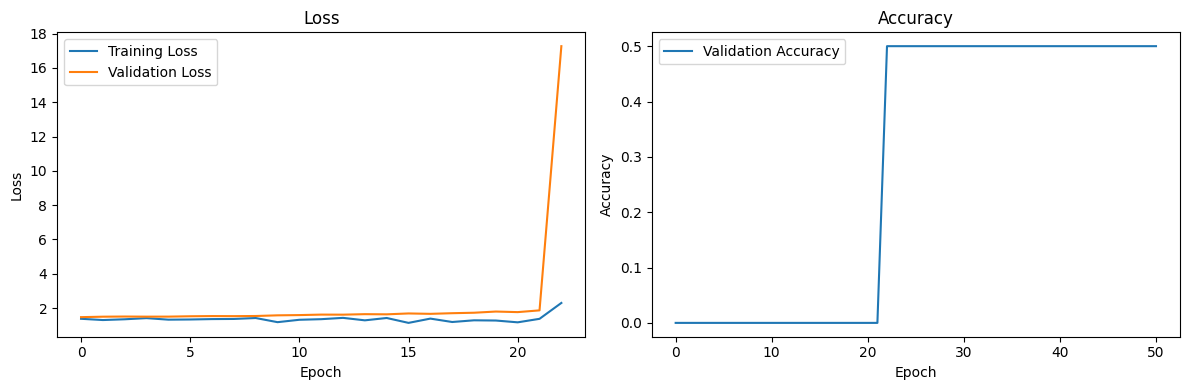

In [ ]:
if __name__ == "__main__":
    # Define intents
    intents = {
        "greeting": {
            "patterns": ["Hi", "Hello", "Hey", "Good morning", "What's up"],
            "responses": ["Hello!", "Hi there!", "Greetings!", "Hey! How can I help you?"]
        },
        "farewell": {
            "patterns": ["Bye", "See you", "Goodbye", "Later", "I'm leaving"],
            "responses": ["Goodbye!", "See you later!", "Farewell!", "Take care!"]
        },
        "thanks": {
            "patterns": ["Thanks", "Thank you", "Much appreciated", "Appreciate it"],
            "responses": ["You're welcome!", "No problem!", "Anytime!", "Glad to help!"]
        },
        "help": {
            "patterns": ["Help", "I need help", "Can you help me", "Support"],
            "responses": ["How can I help you?", "I'm here to assist you.", "What do you need help with?"]
        }
    }

    # Create and train the chatbot
    chatbot = Chatbot()
    chatbot.load_intents(intents)
    chatbot.build_model(hidden_layers=[32, 16])

    # Train the model
    history = chatbot.train(epochs=500, learning_rate=0.01)

    chatbot.plot_training_history(history)

    # Save the model
    chatbot.save_model("chatbot_model.json")

## Test

In [ ]:
  # Start the chat
  chatbot.chat()

Chatbot is online! Type 'quit' to exit.
You: Hi
Chatbot (greeting, nan): Hello!


KeyboardInterrupt: Interrupted by user